<a href="https://colab.research.google.com/github/sowmiya-ai/project/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [27]:
df = pd.read_csv("/content/Palo Alto Networks.csv")

In [28]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [30]:
df.describe()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,0.161224,802.485714,9.192517,2.912925,2.721769,65.891156,2.729932,2.063946,2.728571,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,0.367863,403.509100,8.106864,1.024165,1.093082,20.329428,0.711561,1.106940,1.102846,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,0.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,465.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,0.000000,802.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,0.000000,1157.000000,14.000000,4.000000,4.000000,83.750000,3.000000,3.000000,4.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [31]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
Gender,0


In [32]:
df.drop_duplicates(inplace=True)

**Promotion Gap** **Ratio**

In [33]:
df['PromotionGapRatio']=(
    df['YearsSinceLastPromotion']/(df['YearsAtCompany']+1)
)

In [34]:
df['RoleStagnationIndex'] =(
    df['YearsInCurrentRole'] /
    (df['YearsAtCompany'] + 1)
)

In [35]:
df['TrainingIntensityScore'] = (
    df['TrainingTimesLastYear'] /
    (df['YearsAtCompany'] + 1)
)

In [36]:
df['ManagerStability'] = (
    df['YearsWithCurrManager'] /
    (df['YearsAtCompany'] + 1)
)

In [37]:
le = LabelEncoder()

cat_cols = [
    'BusinessTravel',
    'Department',
    'EducationField',
    'Gender',
    'JobRole',
    'MaritalStatus',
    'OverTime'
]

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [38]:
features = [
    'PromotionGapRatio',
    'RoleStagnationIndex',
    'TrainingIntensityScore',
    'ManagerStability',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'JobLevel',
    'MonthlyIncome'
]

In [39]:
scaler = StandardScaler()
X = scaler.fit_transform(df[features])

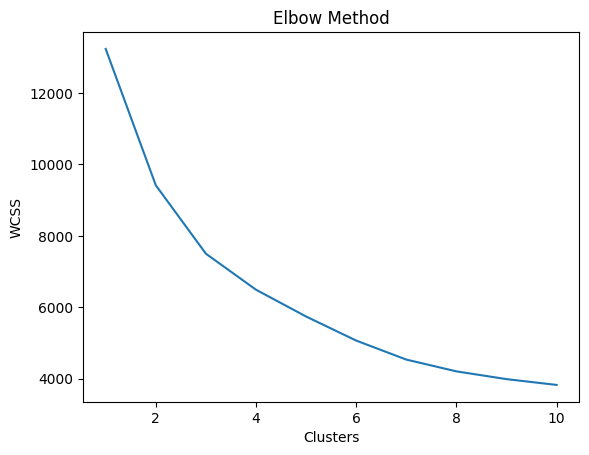

In [40]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [41]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X)

In [42]:
df.groupby('Cluster')[features].mean()

,PromotionGapRatio,RoleStagnationIndex,TrainingIntensityScore,ManagerStability,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,JobLevel,MonthlyIncome
Cluster,,,,,,,,,
0,0.113390,0.444137,0.530290,0.467845,4.525617,2.390892,0.592030,1.510436,4273.787476
1,0.417895,0.475637,0.173698,0.442428,19.299320,8.789116,7.653061,4.095238,15552.714286
2,0.039388,0.026396,1.907626,0.007614,0.837563,0.055838,0.091371,1.654822,4811.192893
3,0.117662,0.679898,0.294990,0.614290,9.671687,7.156627,1.331325,2.503012,8019.213855
4,0.672593,0.643168,0.518607,0.626454,6.382022,4.786517,4.940075,1.794007,5283.108614


In [43]:
conditions = [
    (df['PromotionGapRatio'] < 0.3),
    (df['PromotionGapRatio'] >= 0.3) &(df['PromotionGapRatio']<0.7),
    (df['PromotionGapRatio'] >= 0.7)&(df['PromotionGapRatio']<1.0),
     (df['PromotionGapRatio'] >= 1.0)]
values = ['Low', 'Medium', 'High', 'Very High']

df['PromotionGapRisk'] = np.select(
    conditions,
    values, default='Unknown'
)

In [44]:
retention_df = df[
    (df['Attrition'] == 0) &
    (df['PromotionGapRisk'] == 'High')
]

**EDA VISUAL**

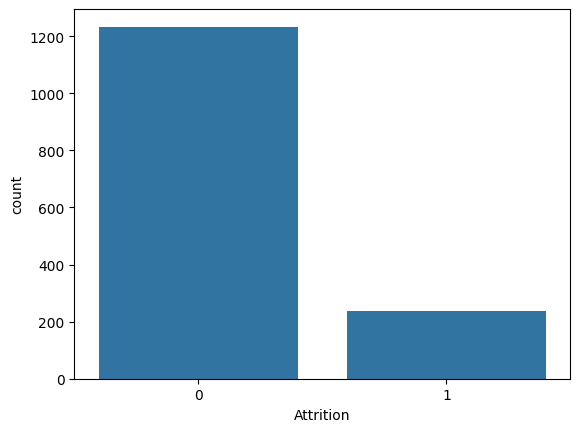

In [45]:
sns.countplot(x='Attrition', data = df)
plt.show()

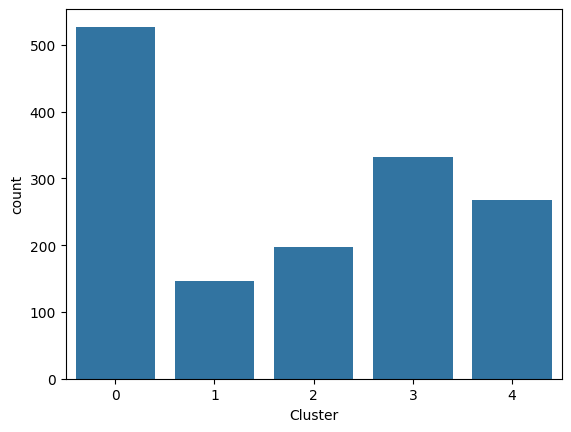

In [46]:
sns.countplot(x= 'Cluster', data = df)
plt.show()

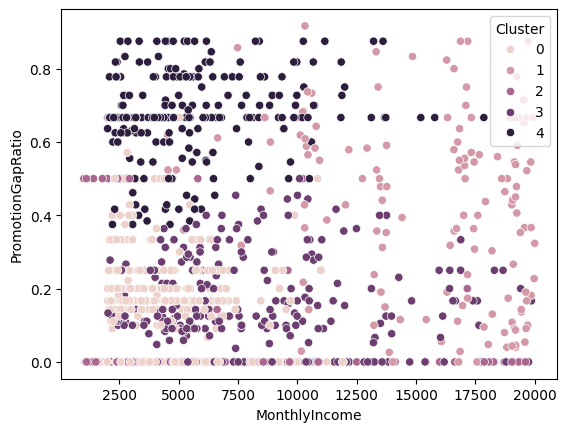

In [47]:
sns.scatterplot(
    x='MonthlyIncome',
    y='PromotionGapRatio',
    hue='Cluster',
    data=df
)
plt.show()

In [48]:
df.to_csv("final_employee_data.csv", index= False)

In [49]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager',
 'PromotionGapRatio',
 'RoleStagnationIndex',
 'TrainingIntensityScore',
 'ManagerStability',
 'Cluster',
 'PromotionGapRisk']

In [50]:
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PromotionGapRatio,RoleStagnationIndex,TrainingIntensityScore,ManagerStability,Cluster,PromotionGapRisk
0,41,1,2,1102,2,1,2,1,2,0,...,6,4,0,5,0.000000,0.571429,0.000000,0.714286,3,Low
1,49,0,1,279,1,8,1,1,3,1,...,10,7,1,7,0.090909,0.636364,0.272727,0.636364,3,Low
2,37,1,2,1373,1,2,2,4,4,1,...,0,0,0,0,0.000000,0.000000,3.000000,0.000000,2,Low
3,33,0,1,1392,1,3,4,1,4,0,...,8,7,3,0,0.333333,0.777778,0.333333,0.000000,0,Medium
4,27,0,2,591,1,2,1,3,1,1,...,2,2,2,2,0.666667,0.666667,1.000000,0.666667,4,Medium
